In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aneesh10/cricket-shot-dataset")

print("Path to dataset files:", path)

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]


x_val = x_train[50000:]
y_val = y_train[50000:]

x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0

x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)


LeNet_Model=Sequential()

LeNet_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))

LeNet_Model.add(AveragePooling2D((2, 2)))

LeNet_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))

LeNet_Model.add(AveragePooling2D((2, 2)))

LeNet_Model.add(Flatten())

LeNet_Model.add(Dense(120, activation='tanh'))
LeNet_Model.add(Dense(84, activation='tanh'))
LeNet_Model.add(Dense(10, activation='softmax'))

LeNet_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
LeNet_Model.summary()
LeNet_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

2026-04-05 18:22:09.635176: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775413329.812495      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775413329.874770      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775413330.294832      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775413330.294872      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775413330.294875      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775413353.170332      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775413353.176106      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

I0000 00:00:1775413356.282913     108 service.cc:152] XLA service 0x7f56b0005320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775413356.282945     108 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775413356.282948     108 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775413356.611066     108 cuda_dnn.cc:529] Loaded cuDNN version 91002


 64/391 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5841 - loss: 1.4730

I0000 00:00:1775413358.960639     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8030 - loss: 0.7010 - val_accuracy: 0.9521 - val_loss: 0.1662
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9522 - loss: 0.1567 - val_accuracy: 0.9656 - val_loss: 0.1156
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.0979 - val_accuracy: 0.9757 - val_loss: 0.0851
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9793 - loss: 0.0695 - val_accuracy: 0.9790 - val_loss: 0.0711
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0554 - val_accuracy: 0.9802 - val_loss: 0.0640
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9858 - loss: 0.0449 - val_accuracy: 0.9818 - val_loss: 0.0602
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9890 - loss: 0.0369 - val_accuracy: 0.9834 - val_loss: 0.0533
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9917 - loss: 0.0279 - val_accuracy: 0.9825 - val

NameError: name 'LeNet5_Model' is not defined

In [ ]:
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0


x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)


y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)


Modern_LeNet = Sequential()
Modern_LeNet.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
Modern_LeNet.add(MaxPooling2D((2, 2)))

Modern_LeNet.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
Modern_LeNet.add(MaxPooling2D((2, 2)))

Modern_LeNet.add(Flatten())

Modern_LeNet.add(Dense(120, activation='relu'))
Modern_LeNet.add(Dense(84, activation='relu'))
Modern_LeNet.add(Dense(10, activation='softmax'))

Modern_LeNet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = Modern_LeNet.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))
test_loss, test_acc = Modern_LeNet.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

First, the final accuracy is higher in the modern model. The original one usually stays around 98.5% to 98.8%, but the modern version consistently crosses 99%. This mainly happens because of max pooling — it keeps the most important features like edges and strokes in digits, instead of smoothing everything like average pooling does.
Second, the modern model learns much faster in the beginning. In the first few epochs itself, the validation accuracy increases quickly. This is because ReLU helps gradients flow better during training, whereas tanh can slow things down due to vanishing gradients.
But there’s also a downside. Since the modern model learns so fast, it can start overfitting after some time. Around epoch 15 or 20, the training loss keeps decreasing, but the validation loss starts increasing slightly. That means the model is beginning to memorize the training data instead of generalizing well.

Difference between LeNet and Moderen LeNet is in LeNet we use tanh as activation function where as in Moderen LeNet we use relu use aviod this missing gradients .
Missing Gradients means during training, the gradients become very small (close to 0), so the network stops learning.Pooling Layer LeNetAveragePooling2D Modern LeNet MaxPooling2D

In [ ]:
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout # Added Dropout
from keras.callbacks import EarlyStopping # Added EarlyStopping
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]

x_val = x_train[50000:]
y_val = y_train[50000:]

x_train_main = x_train_main / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

Modern_LeNet = Sequential()

Modern_LeNet.add(Conv2D(6, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
Modern_LeNet.add(MaxPooling2D((2, 2)))

Modern_LeNet.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
Modern_LeNet.add(MaxPooling2D((2, 2)))

Modern_LeNet.add(Flatten())

Modern_LeNet.add(Dense(120, activation='relu'))
# CHANGE 1: Adding Dropout to randomly turn off 50% of neurons during training
Modern_LeNet.add(Dropout(0.5)) 

Modern_LeNet.add(Dense(84, activation='relu'))
# CHANGE 2: Another Dropout layer
Modern_LeNet.add(Dropout(0.5))

Modern_LeNet.add(Dense(10, activation='softmax'))

Modern_LeNet.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# CHANGE 3: Define the Early Stopping callback
# This watches the validation loss. If it doesn't improve for 3 epochs (patience), training stops.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True # Automatically rolls back to the best performing epoch
)

# CHANGE 4: Add the callbacks parameter to the fit function
# We can safely set epochs=50 now, because EarlyStopping will cut it off when it's done.
history = Modern_LeNet.fit(
    x_train_main, 
    y_train_main, 
    epochs=50, 
    batch_size=128, 
    validation_data=(x_val, y_val),
    callbacks=[early_stop] 
)

test_loss, test_acc = Modern_LeNet.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

When I improved the modern LeNet model, my main goal was to reduce overfitting and make the model more reliable on unseen data.
First, I added Dropout layers after the dense layers. What dropout does is randomly switch off around 50% of the neurons during each training step. Because of this, the network can’t depend too much on any single neuron or pathway. Instead, it’s forced to learn more general and robust patterns. You can think of it like training with a handicap — it makes learning harder during training, but the model becomes stronger during testing.
Next, I used Early Stopping to control overfitting. Instead of training for a fixed number of epochs, the model now keeps checking the validation loss. If the validation loss stops improving and starts getting worse for a few consecutive epochs, training automatically stops. This helps prevent the model from memorizing the training data.
The restore_best_weights=True part is especially useful. Even if the model slightly overfits at the end, it automatically goes back and keeps the weights from the best-performing epoch — the point where validation loss was lowest.

In [ ]:
#AlexNet 
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

# Load data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-hot encoding
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Model
AlexNet_Model = Sequential()


AlexNet_Model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
AlexNet_Model.add(BatchNormalization())
AlexNet_Model.add(MaxPooling2D((2,2)))


AlexNet_Model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
AlexNet_Model.add(BatchNormalization())
AlexNet_Model.add(MaxPooling2D((2,2)))


AlexNet_Model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
AlexNet_Model.add(BatchNormalization()) #Batch Normalisation 
AlexNet_Model.add(MaxPooling2D((2,2)))

# Fully Connected
AlexNet_Model.add(Flatten())

AlexNet_Model.add(Dense(256, activation='relu'))
AlexNet_Model.add(Dropout(0.5))

AlexNet_Model.add(Dense(128, activation='relu'))
AlexNet_Model.add(Dropout(0.5))

AlexNet_Model.add(Dense(10, activation='softmax'))

# Compile
AlexNet_Model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history = AlexNet_Model.fit(
    x_train_main,
    y_train_main,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = AlexNet_Model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

When I implemented the AlexNet-style model, I observed some clear improvements compared to both the original and modern LeNet.
First, the accuracy improved slightly, usually reaching around 99.2% to 99.4% on the test set. This happens because AlexNet is deeper and has more filters, so it can capture more complex patterns in the images compared to LeNet.
Second, the model showed more stable learning during training. Thanks to Batch Normalization, the training process was smoother, and the validation accuracy increased more consistently without large fluctuations.
Another important observation was that the model learns richer features. While LeNet mainly captures basic edges and shapes, AlexNet can learn more detailed patterns due to its deeper architecture and higher number of filters.
However, I also noticed that the model is more prone to overfitting because it has many more parameters. This is why Dropout plays a crucial role here — it helps regularize the model and improves generalization.
Finally, the training time is higher compared to LeNet. Since the model is deeper and more complex, it requires more computation and takes longer to train.

In [ ]:
#AlexNet without Batch Normalisation 
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping

# Load data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-hot
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Model WITHOUT BatchNorm
AlexNet_NoBN = Sequential()

AlexNet_NoBN.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
AlexNet_NoBN.add(MaxPooling2D((2,2)))

AlexNet_NoBN.add(Conv2D(64, (3,3), activation='relu', padding='same'))
AlexNet_NoBN.add(MaxPooling2D((2,2)))

AlexNet_NoBN.add(Conv2D(128, (3,3), activation='relu', padding='same'))
AlexNet_NoBN.add(MaxPooling2D((2,2)))

AlexNet_NoBN.add(Flatten())

AlexNet_NoBN.add(Dense(256, activation='relu'))
AlexNet_NoBN.add(Dropout(0.5))

AlexNet_NoBN.add(Dense(128, activation='relu'))
AlexNet_NoBN.add(Dropout(0.5))

AlexNet_NoBN.add(Dense(10, activation='softmax'))

AlexNet_NoBN.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = AlexNet_NoBN.fit(
    x_train_main,
    y_train_main,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

test_loss, test_acc = AlexNet_NoBN.evaluate(x_test, y_test)
print("Test Accuracy (No BN):", test_acc)

When I removed Batch Normalization from the AlexNet model, I noticed a few important changes in how the model behaved.
First, the training became less stable. The validation accuracy fluctuated more compared to the version with Batch Normalization. Without it, the model struggled to maintain consistent learning across epochs.
Second, the convergence was slower. The model took more epochs to reach a good accuracy because Batch Normalization normally helps in maintaining stable distributions of activations, which speeds up training.
I also observed a slight drop in final accuracy. While the model still performed well, it didn’t reach the same level as the version with Batch Normalization.
Another key point was that the model became more sensitive to hyperparameters, especially the learning rate. Small changes in settings had a bigger impact compared to the normalized version.


In [ ]:
#AlexNet with LeakyRELU
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from keras.callbacks import EarlyStopping

# Load data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-hot
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Model
AlexNet_Leaky = Sequential()

# Block 1
AlexNet_Leaky.add(Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)))
AlexNet_Leaky.add(LeakyReLU(alpha=0.01))
AlexNet_Leaky.add(BatchNormalization())
AlexNet_Leaky.add(MaxPooling2D((2,2)))

# Block 2
AlexNet_Leaky.add(Conv2D(64, (3,3), padding='same'))
AlexNet_Leaky.add(LeakyReLU(alpha=0.01))
AlexNet_Leaky.add(BatchNormalization())
AlexNet_Leaky.add(MaxPooling2D((2,2)))

# Block 3
AlexNet_Leaky.add(Conv2D(128, (3,3), padding='same'))
AlexNet_Leaky.add(LeakyReLU(alpha=0.01))
AlexNet_Leaky.add(BatchNormalization())
AlexNet_Leaky.add(MaxPooling2D((2,2)))

# Dense
AlexNet_Leaky.add(Flatten())

AlexNet_Leaky.add(Dense(256))
AlexNet_Leaky.add(LeakyReLU(alpha=0.01))
AlexNet_Leaky.add(Dropout(0.5))

AlexNet_Leaky.add(Dense(128))
AlexNet_Leaky.add(LeakyReLU(alpha=0.01))
AlexNet_Leaky.add(Dropout(0.5))

AlexNet_Leaky.add(Dense(10, activation='softmax'))

# Compile
AlexNet_Leaky.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history = AlexNet_Leaky.fit(
    x_train_main,
    y_train_main,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = AlexNet_Leaky.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

When I replaced ReLU with LeakyReLU in the AlexNet model, I noticed some changes.
First, the training became slightly more stable, especially in the deeper layers. Since LeakyReLU allows a small gradient even for negative values, it reduces the chances of neurons becoming completely inactive.
Second, the convergence was smoother, with fewer sudden drops or plateaus in validation accuracy. This indicates better gradient flow compared to standard ReLU.
However, the improvement in final accuracy was not very large. On MNIST, both ReLU and LeakyReLU perform quite similarly because the dataset is simple.
The main benefit of LeakyReLU is not huge accuracy gain, but more reliable training and reduced risk of dead neurons, especially in deeper networks.


In [ ]:
#VGG NET
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

# Load data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-hot
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Model
VGG_Model = Sequential()

# Block 1
VGG_Model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
VGG_Model.add(BatchNormalization())
VGG_Model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
VGG_Model.add(BatchNormalization())
VGG_Model.add(MaxPooling2D((2,2)))

# Block 2
VGG_Model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGG_Model.add(BatchNormalization())
VGG_Model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGG_Model.add(BatchNormalization())
VGG_Model.add(MaxPooling2D((2,2)))

# Block 3
VGG_Model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
VGG_Model.add(BatchNormalization())
VGG_Model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
VGG_Model.add(BatchNormalization())
VGG_Model.add(MaxPooling2D((2,2)))

# Dense
VGG_Model.add(Flatten())

VGG_Model.add(Dense(256, activation='relu'))
VGG_Model.add(Dropout(0.5))

VGG_Model.add(Dense(128, activation='relu'))
VGG_Model.add(Dropout(0.5))

VGG_Model.add(Dense(10, activation='softmax'))

# Compile
VGG_Model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history = VGG_Model.fit(
    x_train_main,
    y_train_main,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = VGG_Model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

When I implemented the VGG-style model, I noticed that the network was able to learn more detailed and refined features compared to both LeNet and AlexNet.
First, the accuracy improved slightly, often reaching around 99.3% or higher. This is because stacking multiple 3×3 convolution layers allows the model to capture more complex patterns step by step.
Second, the feature extraction was much richer. Instead of learning simple edges like in LeNet, the model could learn more detailed structures due to its deeper architecture.
However, I also observed that the model is heavier and slower to train. Since it has more layers and parameters, training takes more time and requires more computation.
Another important point is that the model has a higher risk of overfitting, which is why Dropout and Batch Normalization are essential to maintain good generalization.

In [ ]:
#VGG NET
import keras
from keras import datasets
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

# Load data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

x_train_main = x_train[:50000] / 255.0
y_train_main = y_train[:50000]

x_val = x_train[50000:] / 255.0
y_val = y_train[50000:]

x_test = x_test / 255.0

# Reshape
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# One-hot
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Model
# ADDING EXTRA BLOCK (Block 4)

VGG_Deep = Sequential()

# Block 1
VGG_Deep.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(Conv2D(32, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(MaxPooling2D((2,2)))

# Block 2
VGG_Deep.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(MaxPooling2D((2,2)))

# Block 3
VGG_Deep.add(Conv2D(128, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(Conv2D(128, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(MaxPooling2D((2,2)))

# NEW Block 4 🔥
VGG_Deep.add(Conv2D(256, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(Conv2D(256, (3,3), activation='relu', padding='same'))
VGG_Deep.add(BatchNormalization())
VGG_Deep.add(MaxPooling2D((2,2)))

# Dense
VGG_Deep.add(Flatten())

VGG_Deep.add(Dense(256, activation='relu'))
VGG_Deep.add(Dropout(0.5))

VGG_Deep.add(Dense(128, activation='relu'))
VGG_Deep.add(Dropout(0.5))

VGG_Deep.add(Dense(10, activation='softmax'))

VGG_Deep.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = VGG_Deep.fit(
    x_train_main, y_train_main,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

test_loss, test_acc = VGG_Deep.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)



When I increased the depth of the VGG model by adding an extra convolutional block, I noticed a few interesting changes.
First, the model was able to learn slightly more complex patterns, but the improvement in accuracy was not very significant. Since MNIST is a simple dataset, the additional depth didn’t provide much benefit.
Second, the training time increased noticeably. The deeper model required more computation and took longer to converge.
I also observed that the model became more prone to overfitting. Even with Dropout and Batch Normalization, the gap between training and validation performance slightly increased.
Overall, this experiment showed that simply increasing depth does not always guarantee better performance, especially for simpler datasets.


Found 4723 files belonging to 4 classes.
Using 3779 files for training.
Found 4723 files belonging to 4 classes.
Using 944 files for validation.
Classes found: ['drive', 'legglance-flick', 'pullshot', 'sweep']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,496 (240.22 KB)

 Trainable params: 61,496 (240.22 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.3736 - loss: 1.3474 - val_accuracy: 0.5275 - val_loss: 1.1943
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5797 - loss: 1.0729 - val_accuracy: 0.5604 - val_loss: 1.0324
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.6240 - loss: 0.9389 - val_accuracy: 0.6239 - val_loss: 0.9594
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6637 - loss: 0.8649 - val_accuracy: 0.6589 - val_loss: 0.9124
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.6881 - loss: 0.8104 - val_accuracy: 0.6642 - val_loss: 0.9133
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7167 - loss: 0.7827 - val_accuracy: 0.6981 - val_loss: 0.8655
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.7324 - loss: 0.7391 - val_accuracy: 0.6949 - val_loss: 0.8562
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.7411 - 

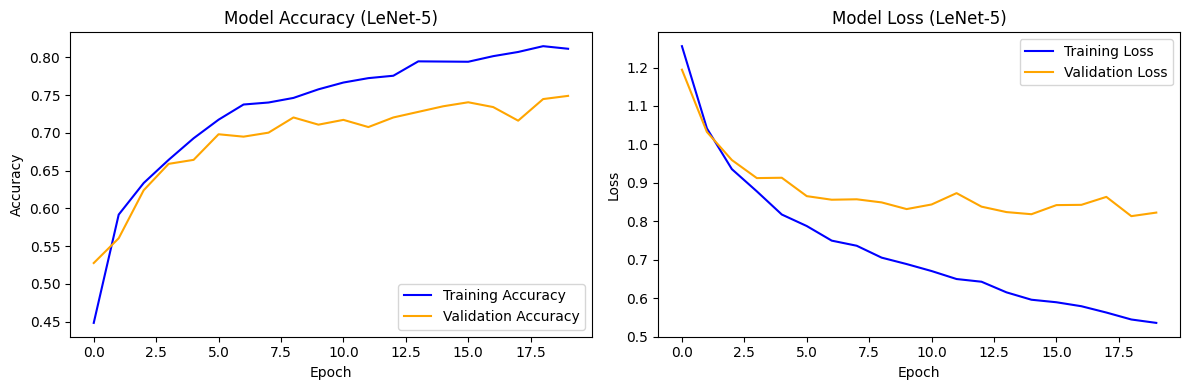

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt

data_dir = '/kaggle/input/datasets/aneesh10/cricket-shot-dataset/data/'

# Set parameters
batch_size = 32
img_height = 32
img_width = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)
class_names = train_ds.class_names
print("Classes found:", class_names)
num_classes = len(class_names)

# Model
LeNet_Model = Sequential()
LeNet_Model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))
# Layer 1
LeNet_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh'))
LeNet_Model.add(AveragePooling2D(pool_size=(2, 2)))

# Layer 2
LeNet_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
LeNet_Model.add(AveragePooling2D(pool_size=(2, 2)))

# Flatten to 1D
LeNet_Model.add(Flatten())

# Fully Connected Layers
LeNet_Model.add(Dense(120, activation='tanh'))
LeNet_Model.add(Dense(84, activation='tanh'))

# Output Layer
LeNet_Model.add(Dense(num_classes, activation='softmax'))
LeNet_Model.summary()

# Compile
LeNet_Model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', # Use sparse because our labels are integers
    metrics=['accuracy']
)

# Train the model
print("Starting training...")
epochs = 20
history = LeNet_Model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)



# Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy (LeNet-5)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss (LeNet-5)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Found 4723 files belonging to 4 classes.
Using 3779 files for training.
Found 4723 files belonging to 4 classes.
Using 944 files for validation.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,297,732 (222.39 MB)

 Trainable params: 58,297,732 (222.39 MB)

 Non-trainable params: 0 (0.00 B)

Starting AlexNet training...
Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step - accuracy: 0.2527 - loss: 2.6732 - val_accuracy: 0.2267 - val_loss: 1.3917
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.2605 - loss: 1.3881 - val_accuracy: 0.2267 - val_loss: 1.3914
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.2642 - loss: 1.3858 - val_accuracy: 0.2267 - val_loss: 1.3893
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.2588 - loss: 1.3860 - val_accuracy: 0.2267 - val_loss: 1.3901
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.2596 - loss: 1.3850 - val_accuracy: 0.2267 - val_loss: 1.3900
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.2510 - loss: 1.3865 - val_accuracy: 0.2267 - val_loss: 1.3889
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.2574 - loss: 1.3868 - val_accuracy: 0.2267 - val_loss: 1.3893
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0

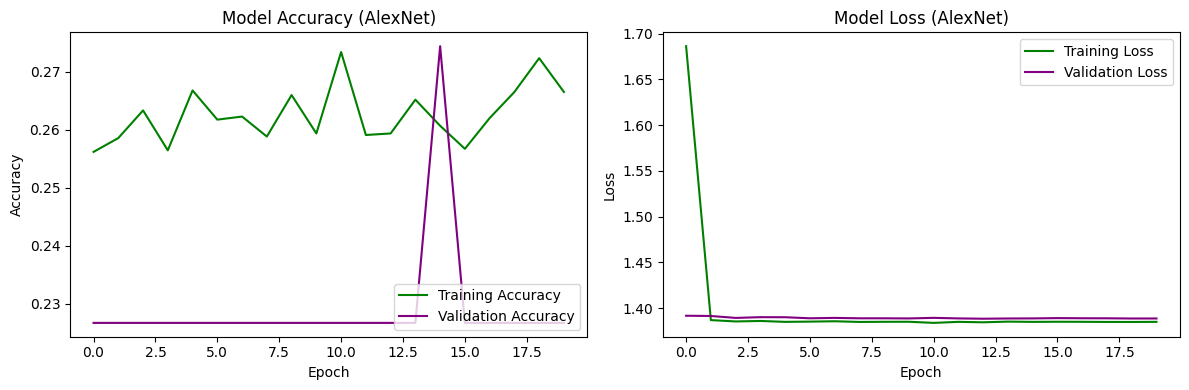

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
data_dir = '/kaggle/input/datasets/aneesh10/cricket-shot-dataset/data/'

batch_size = 32
# AlexNet historically takes 227x227 images
img_height = 227 
img_width = 227

# Load the training data 
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load the validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

AlexNet_Model = Sequential()

# Rescaling pixel
AlexNet_Model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# Layer 1:
AlexNet_Model.add(Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu'))
AlexNet_Model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 2: 5x5 filters
AlexNet_Model.add(Conv2D(filters=256, kernel_size=(5, 5), padding='same', activation='relu'))
AlexNet_Model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 3, 4, 5: Three Convolutional layers stacked together without pooling in between
AlexNet_Model.add(Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
AlexNet_Model.add(Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
AlexNet_Model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
AlexNet_Model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Flatten to 1D
AlexNet_Model.add(Flatten())

# Layer 6: First Massive Fully Connected Layer with Dropout
AlexNet_Model.add(Dense(4096, activation='relu'))
AlexNet_Model.add(Dropout(0.5)) # Turns off 50% of neurons randomly to prevent overfitting

# Layer 7: Second Massive Fully Connected Layer with Dropout
AlexNet_Model.add(Dense(4096, activation='relu'))
AlexNet_Model.add(Dropout(0.5))

# Output Layer
AlexNet_Model.add(Dense(num_classes, activation='softmax'))

AlexNet_Model.summary()


AlexNet_Model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting AlexNet training...")
epochs = 20
history_alexnet = AlexNet_Model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_alexnet.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_alexnet.history['val_accuracy'], label='Validation Accuracy', color='purple')
plt.title('Model Accuracy (AlexNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history_alexnet.history['loss'], label='Training Loss', color='green')
plt.plot(history_alexnet.history['val_loss'], label='Validation Loss', color='purple')
plt.title('Model Loss (AlexNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Found 4723 files belonging to 4 classes.
Using 3779 files for training.
Found 4723 files belonging to 4 classes.
Using 944 files for validation.
Starting VGG-16 Transfer Learning...
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 60s 359ms/step - accuracy: 0.6420 - loss: 10.2611 - val_accuracy: 0.8803 - val_loss: 0.3241
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 228ms/step - accuracy: 0.8794 - loss: 0.4657 - val_accuracy: 0.9047 - val_loss: 0.2757
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 238ms/step - accuracy: 0.9033 - loss: 0.3437 - val_accuracy: 0.9333 - val_loss: 0.1982
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 239ms/step - accuracy: 0.9257 - loss: 0.2362 - val_accuracy: 0.9322 - val_loss: 0.1818
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.9341 - loss: 0.2288 - val_accuracy: 0.9417 - val_loss: 0.1989
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 28s 235ms/step - accuracy: 0.9280 - loss: 0.2463 - val_accuracy: 0.9523 - val_loss: 0.1850
Epoch 7/15
119/119 ━━━━━━━━━━━━

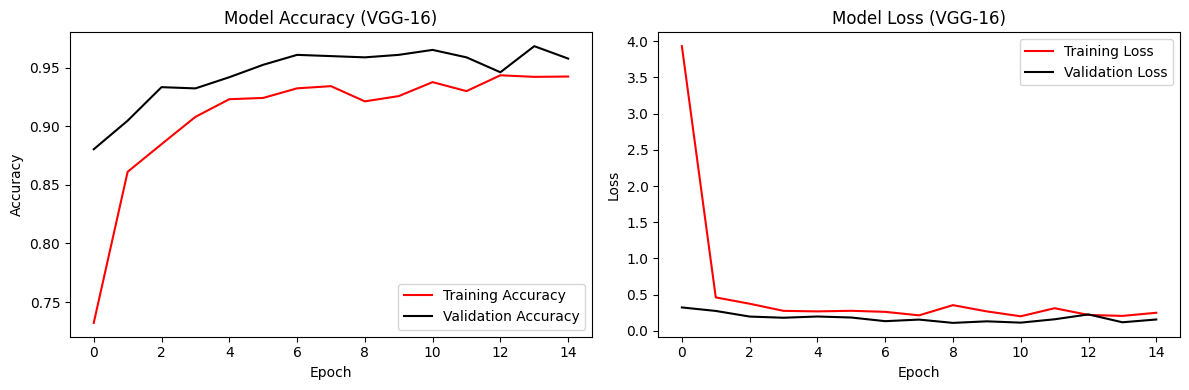

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

data_dir = '/kaggle/input/datasets/aneesh10/cricket-shot-dataset/data/'

batch_size = 32
# VGG natively expects 224x224 images
img_height = 224 
img_width = 224

# Load the training data 
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load the validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)


# A. Load the pre-trained VGG16 model
base_model = VGG16(
    weights='imagenet', 
    include_top=False, 
    input_shape=(img_height, img_width, 3)
)

# B. Freeze the base model (We don't want to destroy its pre-trained knowledge)
base_model.trainable = False 

# C. Build our custom top on it
VGG_Model = models.Sequential()

# VGG expects images scaled specifically 
VGG_Model.add(layers.Lambda(tf.keras.applications.vgg16.preprocess_input))

# Add the frozen VGG brain
VGG_Model.add(base_model)

# Flatten the output of VGG into a 1D vector
VGG_Model.add(layers.Flatten())
VGG_Model.add(layers.Dense(256, activation='relu'))
VGG_Model.add(layers.Dropout(0.5)) # Heavy dropout to prevent overfitting

# Output Layer (2 classes: Drive vs Leg Glance)
VGG_Model.add(layers.Dense(num_classes, activation='softmax'))


VGG_Model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting VGG-16 Transfer Learning...")
epochs = 15
history_vgg = VGG_Model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy', color='red')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy', color='black')
plt.title('Model Accuracy (VGG-16)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Training Loss', color='red')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss', color='black')
plt.title('Model Loss (VGG-16)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Found 4723 files belonging to 4 classes.
Using 3779 files for training.
Found 4723 files belonging to 4 classes.
Using 944 files for validation.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Starting ResNet-50 Transfer Learning...
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 37s 212ms/step - accuracy: 0.4376 - loss: 1.5277 - val_accuracy: 0.8591 - val_loss: 0.4561
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.7527 - loss: 0.6500 - val_accuracy: 0.9195 - val_loss: 0.3080
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.8131 - loss: 0.4811 - val_accuracy: 0.9354 - val_loss: 0.2432
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.8684 - loss: 0.3786 - val_accuracy: 0.9364 - val_loss: 0.2253
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.8876 - loss: 0.3117 - val_accuracy: 0.9555 - val_loss: 0.1743
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.8972 - loss: 0.2776 - val_accuracy: 0.9619 - val_loss: 0.1568
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - accuracy: 0.9070 - loss: 0.2728 - val_accuracy: 0.9672 - val_loss: 0.1345
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s

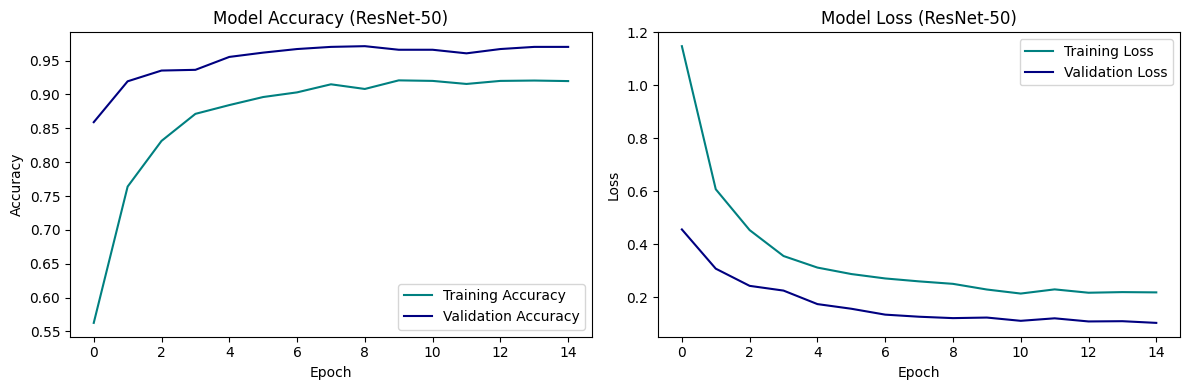

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

data_dir = '/kaggle/input/datasets/aneesh10/cricket-shot-dataset/data/'

batch_size = 32
img_height = 224 # ResNet
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
base_model_resnet = ResNet50(
    weights='imagenet', 
    include_top=False, 
    input_shape=(img_height, img_width, 3)
)
base_model_resnet.trainable = False 
ResNet_Model = models.Sequential()

# ResNet requires its own specific preprocessing math!
# We wrap it in a Lambda layer just like we did for VGG
ResNet_Model.add(layers.Lambda(tf.keras.applications.resnet50.preprocess_input, input_shape=(img_height, img_width, 3)))

# Add the frozen ResNet brain
ResNet_Model.add(base_model_resnet)

# NEW UPGRADE: Instead of Flatten(), we use GlobalAveragePooling2D()
# This takes the 2D feature maps and averages them into a 1D vector. 
# It is much faster and less prone to overfitting than Flattening.
ResNet_Model.add(layers.GlobalAveragePooling2D())

# Optional: Add a Dropout layer for extra safety against overfitting
ResNet_Model.add(layers.Dropout(0.5))

# Output Layer
ResNet_Model.add(layers.Dense(num_classes, activation='softmax'))
ResNet_Model.summary()

ResNet_Model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting ResNet-50 Transfer Learning...")
epochs = 15
history_resnet = ResNet_Model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)



plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy', color='teal')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy', color='navy')
plt.title('Model Accuracy (ResNet-50)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Training Loss', color='teal')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss', color='navy')
plt.title('Model Loss (ResNet-50)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Found 4723 files belonging to 4 classes.
Using 3779 files for training.
Found 4723 files belonging to 4 classes.
Using 944 files for validation.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,276,996 (222.31 MB)

 Trainable params: 58,276,996 (222.31 MB)

 Non-trainable params: 0 (0.00 B)

Starting ZFNet training...
Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 141ms/step - accuracy: 0.2534 - loss: 1.8724 - val_accuracy: 0.2267 - val_loss: 1.3928
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.2478 - loss: 1.3869 - val_accuracy: 0.2267 - val_loss: 1.3911
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.2615 - loss: 1.3869 - val_accuracy: 0.2267 - val_loss: 1.3890
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.2596 - loss: 1.3856 - val_accuracy: 0.2267 - val_loss: 1.3900
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.2542 - loss: 1.3850 - val_accuracy: 0.2267 - val_loss: 1.3892
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.2504 - loss: 1.3859 - val_accuracy: 0.2267 - val_loss: 1.3889
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.2545 - loss: 1.3858 - val_accuracy: 0.2267 - val_loss: 1.3893
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accura

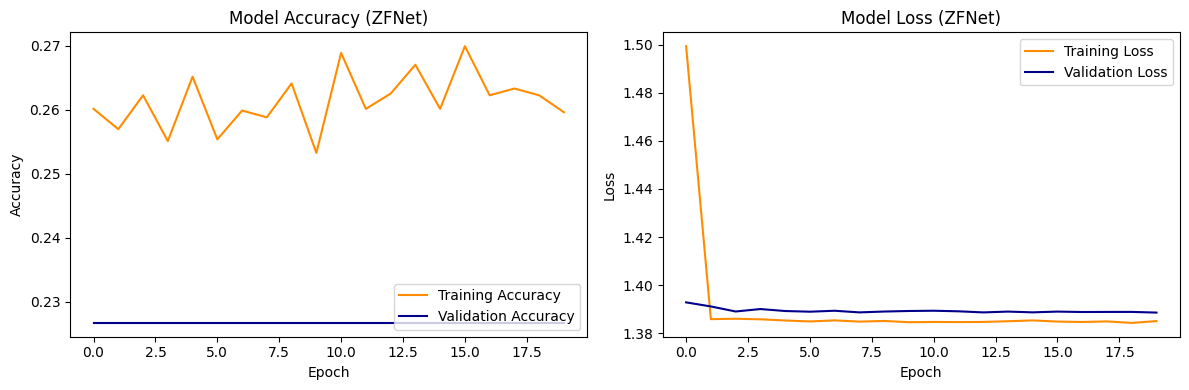

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt


data_dir = '/kaggle/input/datasets/aneesh10/cricket-shot-dataset/data/'

batch_size = 32
img_height = 224 # ZFNet standardizes back to 224x224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)


ZFNet_Model = Sequential()

# Rescaling pixel values to [0, 1]
ZFNet_Model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

# THE ZFNET UPGRADE: 
# Shrinking the kernel to 7x7 and the stride to 2x2.
# This keeps more spatial information than AlexNet.
# ----------------------------------------------------
ZFNet_Model.add(Conv2D(filters=96, kernel_size=(7, 7), strides=(2, 2), activation='relu'))
ZFNet_Model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 2: 5x5 filters, but with stride 2
ZFNet_Model.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(2, 2), padding='same', activation='relu'))
ZFNet_Model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 3, 4, 5: Same as AlexNet, but ZFNet adjusted filter sizes slightly in some paper variations. 
# We'll use the standard configuration.
ZFNet_Model.add(Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
ZFNet_Model.add(Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
ZFNet_Model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
ZFNet_Model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Flatten to 1D
ZFNet_Model.add(Flatten())

# Layer 6: First Massive Fully Connected Layer with Dropout
ZFNet_Model.add(Dense(4096, activation='relu'))
ZFNet_Model.add(Dropout(0.5))

# Layer 7: Second Massive Fully Connected Layer with Dropout
ZFNet_Model.add(Dense(4096, activation='relu'))
ZFNet_Model.add(Dropout(0.5))

# Output Layer
ZFNet_Model.add(Dense(num_classes, activation='softmax'))

ZFNet_Model.summary()


ZFNet_Model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting ZFNet training...")
epochs = 20
history_zfnet = ZFNet_Model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_zfnet.history['accuracy'], label='Training Accuracy', color='darkorange')
plt.plot(history_zfnet.history['val_accuracy'], label='Validation Accuracy', color='darkblue')
plt.title('Model Accuracy (ZFNet)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history_zfnet.history['loss'], label='Training Loss', color='darkorange')
plt.plot(history_zfnet.history['val_loss'], label='Validation Loss', color='darkblue')
plt.title('Model Loss (ZFNet)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Found 4723 files belonging to 4 classes.
Using 3779 files for training.
Found 4723 files belonging to 4 classes.
Using 944 files for validation.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Starting InceptionV3 Transfer Learning...
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 324ms/step - accuracy: 0.4330 - loss: 1.3008 - val_accuracy: 0.8220 - val_loss: 0.6914
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.7275 - loss: 0.7562 - val_accuracy: 0.8485 - val_loss: 0.5290
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accuracy: 0.7797 - loss: 0.6358 - val_accuracy: 0.9047 - val_loss: 0.4163
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.8184 - loss: 0.5381 - val_accuracy: 0.9036 - val_loss: 0.3827
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 145ms/step - accuracy: 0.8412 - loss: 0.4758 - val_accuracy: 0.9184 - val_loss: 0.3304
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 148ms/step - accuracy: 0.8565 - loss: 0.4307 - val_accuracy: 0.9131 - val_loss: 0.3156
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8709 - loss: 0.4034 - val_accuracy: 0.9227 - val_loss: 0.2905
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 1

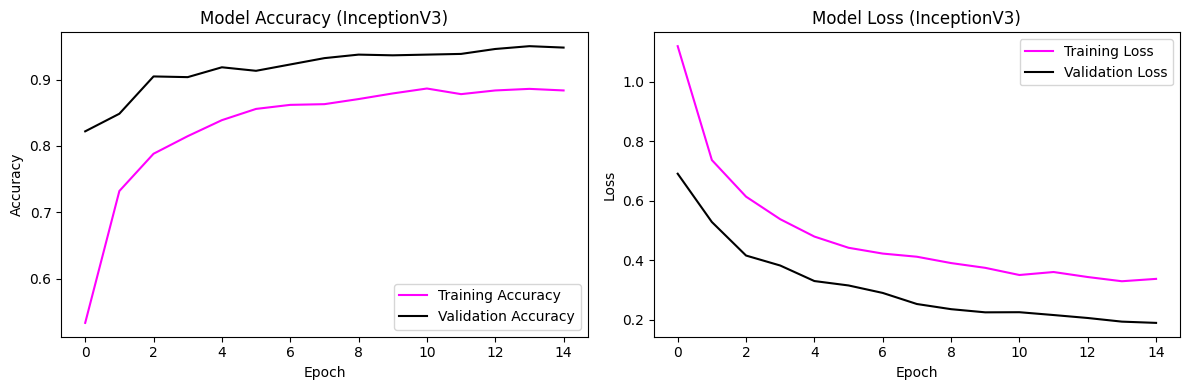

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
import matplotlib.pyplot as plt

data_dir = '/kaggle/input/datasets/aneesh10/cricket-shot-dataset/data/'

batch_size = 32
img_height = 299 
img_width = 299

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
base_model_inception = InceptionV3(
    weights='imagenet', 
    include_top=False, 
    input_shape=(img_height, img_width, 3)
)

base_model_inception.trainable = False 
Inception_Model = models.Sequential()
Inception_Model.add(layers.Lambda(tf.keras.applications.inception_v3.preprocess_input, input_shape=(img_height, img_width, 3)))
Inception_Model.add(base_model_inception)


# We use GlobalAveragePooling2D
Inception_Model.add(layers.GlobalAveragePooling2D())
Inception_Model.add(layers.Dropout(0.5))

# Output Layer
Inception_Model.add(layers.Dense(num_classes, activation='softmax'))

Inception_Model.summary()


Inception_Model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting InceptionV3 Transfer Learning...")
epochs = 15
history_inception = Inception_Model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_inception.history['accuracy'], label='Training Accuracy', color='magenta')
plt.plot(history_inception.history['val_accuracy'], label='Validation Accuracy', color='black')
plt.title('Model Accuracy (InceptionV3)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history_inception.history['loss'], label='Training Loss', color='magenta')
plt.plot(history_inception.history['val_loss'], label='Validation Loss', color='black')
plt.title('Model Loss (InceptionV3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()